This is a notebook for computing deep foundation axial geotechnical capacity. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
#import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

In [ ]:
from nb_utlis import find_project_root

from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection, CrossSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.geomaterials.layer import Layer
from deep_foundation_bearing_capacity.geomaterials.rock import Rock
from deep_foundation_bearing_capacity.geomaterials.soil import Soil
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import (
    SideResistance,
    SideResistanceContext,
    SoilEndResistance,
)

In [ ]:
PROJECT_ROOT = _find_project_root()


In [43]:
# Read soil parameters from YAML
with open(PROJECT_ROOT/"data/soil_params.yaml") as f:
    soils_dict = yaml.safe_load(f)

soil_list = []
for soil_dict in soils_dict:
    soil_dict = Soil.from_dict(soil_dict)
    soil_list.append(soil_dict)

    soil_dict.display_properties()
    print()
    

soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 10

soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 19

soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 6
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 26

soil_index is: 7
unit_weight is: 130.0
cohesion is: 200.0
friction_angle is: 0.0
n60 is: 26

soil_index is: 8
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 20

soil_index is: 9
unit_weight is: 130.0
cohesion is: 8000.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 10
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is:

In [44]:
# Read layer parameters from YAML

with open(PROJECT_ROOT/"data/layer_params.yaml") as f:
    layers_dict = yaml.safe_load(f)


layer_list = []
for layer_dict in layers_dict:
    layer = Layer.from_dict(layer_dict)
    layer_list.append(layer)

# Manually assign geomaterial
for layer, soil in zip(layer_list, soil_list):
    layer.geomaterial = soil

for layer in layer_list:
    layer.display_properties(display_geomaterial = True)
    print()

layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10
soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5
soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10
soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 10

layer_index is: 3
ground_water_depth is: 15.0
top_depth is: 25
thickness is: 10
soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

layer_index is: 4
ground_water_depth is: 15.0
top_depth is: 35
thickness is: 10
soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 19

layer_index is: 5
ground_water_depth is: 15.0
top_depth is: 45
thickness is: 10
soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
fri

In [45]:
# test SideResistance class for cohesionless layer
side_resistance_obj_1 = SideResistance.for_material(layer_list[0])

side_resistance_context = SideResistanceContext(effective_stress = 600)

print(f"First layer beta is: {side_resistance_obj_1._calculate_beta(600):.2f}")
print(f"First layer phi prime is: {side_resistance_obj_1._calculate_phi_prime(600)}")
print(f"First layer ko is: {side_resistance_obj_1._calculate_ko(600)}")
print(f"First layer unit side resistance is: {side_resistance_obj_1.side_resistance_unit(side_resistance_context)}")

# test SideResistance class for cohesive layer
side_resistance_obj_2 = SideResistance.for_material(layer_list[1])
print(f"Second layer alpha is: {side_resistance_obj_2._calculate_alpha():.2f}")

First layer beta is: 0.40
First layer phi prime is: 32.70987923634994
First layer ko is: 0.8809471432730439
First layer unit side resistance is: 239.62616460750564
Second layer alpha is: 0.55


In [46]:
# test EndResistance class for cohesionless layer
end_resistance_obj_1 = SoilEndResistance(layer_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit():.2f}")

Top layer unit end resistance is: 6000.00


In [47]:
# test EndResistance class for cohesionless layer
end_resistance_obj_2 = SoilEndResistance(layer_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit():.2f}")

Second layer unit end resistance is: 3250.00


In [48]:
# test CrossSection class
cross_section_diameter = 1.5
print(f"Cross section diameter is: {cross_section_diameter}")
cross_section_obj = CircularSection(1.5)
print(f"Cross section area is: {cross_section_obj.cross_section_area:.2f}")
print(f"Cross section perimeter is: {cross_section_obj.perimeter:.2f}")

Cross section diameter is: 1.5
Cross section area is: 1.77
Cross section perimeter is: 4.71


In [49]:
# test Segment class
segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer in layer_list:
    segment_obj = Segment(cross_section_obj, layer, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)



In [50]:
print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


In [51]:
# test FactorOfSafety class
fs = 3.0
print(f"Factor of safety is prescribed as: {fs}")
fs_obj = FactorOfSafetyDeepFoundation(1, 1)

Factor of safety is prescribed as: 3.0


In [52]:
# test DeepFoundation class
top_depth = 0

deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None, fs =fs_obj)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")

0.0
0.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
Concrete foundation self weight is: 19456 lb.


In [53]:
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Deep foundation effective stresses are: [600.0, 1500.0, 2063.0, 2589.0, 3190.0, 3866.0, 4542.0, 5218.0, 5894.0, 6570.0, 7171.0, 7722.0]


In [54]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = False)

[11292.116975082572,
 6479.534848028948,
 58087.66413196619,
 51836.27878423158,
 97137.89961145465,
 94247.77960769378,
 97235.6982664023,
 5183.627878423159,
 81247.81975530267,
 169646.00329384883,
 84481.35344584651,
 25918.13939211579]

In [55]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = True)

[8469.087731311929,
 6479.534848028948,
 43565.74809897464,
 51836.27878423158,
 72853.42470859097,
 94247.77960769378,
 72926.77369980172,
 5183.627878423159,
 60935.864816477,
 169646.00329384883,
 63361.01508438489,
 25918.13939211579]

In [56]:
# test DeepFoundation accumulative side resistance 
for segment_side_resistance_accumulative, segment_end_resistance in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances()
):
    print(f"{segment_side_resistance_accumulative:.0f}, {segment_end_resistance:.0f}")

11292, 10603
17772, 5743
75859, 21206
127696, 31809
224833, 40291
319081, 63617
416317, 55135
421501, 2297
502748, 42412
672394, 127235
756876, 63617
782794, 14137


In [57]:
# test DeepFoundation accumulative compression resistance
print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_compression_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
21895 lb.
23515 lb.
97065 lb.
159504 lb.
265124 lb.
382699 lb.
471452 lb.
423798 lb.
545160 lb.
799629 lb.
820493 lb.
796931 lb.


In [58]:
# test DeepFoundation calculate_segment_weights_accumulative
print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 
0.0
0.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0


[2650.718801466388,
 3976.078202199582,
 5524.097982255953,
 7072.117762312324,
 8620.137542368695,
 10168.157322425066,
 11716.177102481437,
 13264.196882537808,
 14812.216662594179,
 16360.23644265055,
 17908.25622270692,
 19456.27600276329]

In [59]:
# test DeepFoundation accumulative uplift resistance
print("Accumulative uplift resistance is:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative uplift resistance is:
0.0
0.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
11120 lb.
18925 lb.
64038 lb.
117423 lb.
191824 lb.
287620 lb.
362095 lb.
368826 lb.
431310 lb.
602504 lb.
667413 lb.
694880 lb.


In [60]:
# Test plotting compression accumulative resistancedeep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

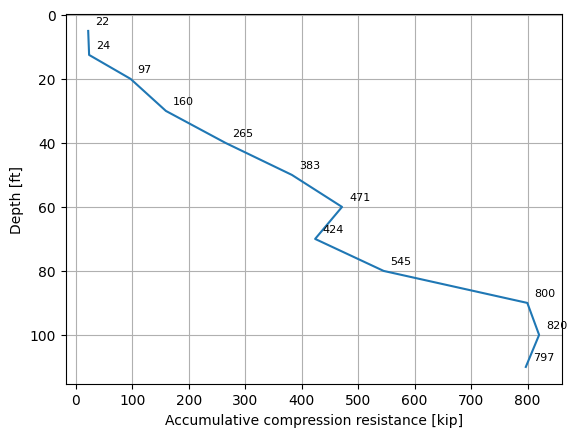

In [61]:
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

0.0
0.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0


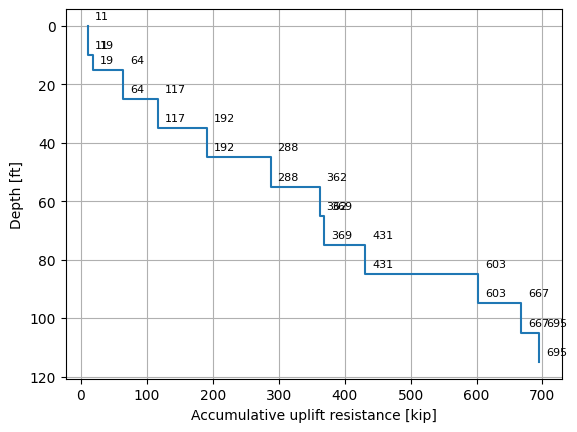

In [62]:
# Test plotting uplift accumulative resistance
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


0.0
0.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0
876.0


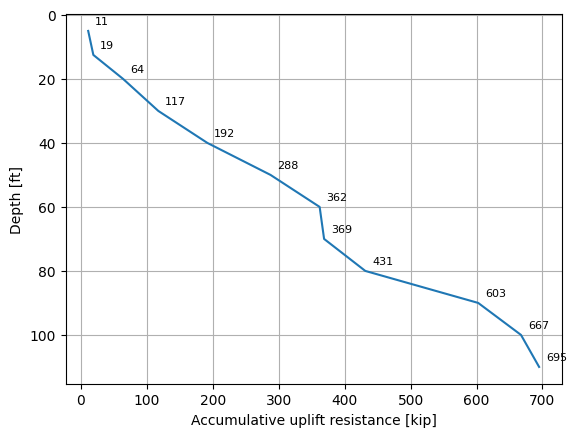

In [63]:
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

In [64]:
# Test structural compression capacity
print("Each segment's structural capacity in compression is: ")
deep_foundation_obj.segments_structural_capacity_compression()

Each segment's structural capacity in compression is: 


[335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207]

In [65]:
# Test side resistance correction
#deep_foundation_obj = DeepFoundation([segment_obj_1, segment_obj_2], top_depth, resistance_correction=True)
#print(f"With depth correction, second segment side resistance is: {deep_foundation_obj.segments[1].side_resistance}")